In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  root_mean_squared_error , r2_score , mean_absolute_error
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib

In [6]:
df=pd.read_csv('../data/almaty_housing_dataset.csv')

In [7]:
df.head()

,latitude,longitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,district,building_type,floor,total_floors,ceiling_height,rooms,total_area,metro_distance_km,proximity
0,43.2500,76.9751,3.9,2,2,146,71,59.4378,57052454.3,Бостандыкский,панельный,3,16,2.59,2,57.3,5.91,ГОРЫ
1,43.3233,76.9412,20.5,1,1,72,25,51.9898,26030799.5,Турксибский,панельный,7,16,2.52,1,40.3,3.70,ОКРАИНА
2,43.3244,76.8898,3.7,3,2,132,53,50.8767,39670076.9,Турксибский,панельный,2,5,3.09,2,53.1,6.04,ОКРАИНА
3,43.3737,76.8888,5.5,3,1,101,39,50.8748,20994180.3,Турксибский,панельный,2,9,2.81,1,37.0,10.89,ОКРАИНА
4,43.3004,76.9615,12.3,4,3,98,39,24.5934,45134327.6,Турксибский,панельный,15,20,2.85,3,61.9,2.66,ОКРАИНА


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   latitude            5000 non-null   float64
 1   longitude           5000 non-null   float64
 2   housing_median_age  5000 non-null   float64
 3   total_rooms         5000 non-null   int64  
 4   total_bedrooms      5000 non-null   int64  
 5   population          5000 non-null   int64  
 6   households          5000 non-null   int64  
 7   median_income       5000 non-null   float64
 8   median_house_value  5000 non-null   float64
 9   district            5000 non-null   str    
 10  building_type       5000 non-null   str    
 11  floor               5000 non-null   int64  
 12  total_floors        5000 non-null   int64  
 13  ceiling_height      5000 non-null   float64
 14  rooms               5000 non-null   int64  
 15  total_area          5000 non-null   float64
 16  metro_distance_km

| Колонка                            | Описание                                                        |
| ---------------------------------- | --------------------------------------------------------------- |
| `latitude` / `longitude`           | Координаты (43.17–43.38, 76.82–77.00)                           |
| `housing_median_age`               | Возраст дома (1–52 лет)                                         |
| `total_rooms`                      | Общее количество комнат                                         |
| `total_bedrooms`                   | Количество спален                                               |
| `population`                       | Население в доме                                                |
| `households`                       | Количество домохозяйств                                         |
| `median_income`                    | Медианный доход (×10,000 KZT)                                   |
| `median_house_value`               | Цена квартиры (KZT)                                             |
| `district`                         | Район (8 районов Алматы)                                        |
| `building_type`                    | Тип здания (панельный/кирпичный/монолитный/каркасно-монолитный) |
| `floor`                            | Этаж                                                            |
| `total_floors`                     | Всего этажей в доме                                             |
| `ceiling_height`                   | Высота потолков (м)                                             |
| `rooms`                            | Количество комнат (1–5)                                         |
| `total_area`                       | Общая площадь (кв.м)                                            |
| `metro_distance_km`                | Расстояние до метро (км)                                        |
| `proximity` / `location_proximity` | Локация (ЦЕНТР/БЛИЗ ЦЕНТРА/СПАЛЬНЫЙ/ОКРАИНА/ГОРЫ)               |


In [9]:
df.drop(
    ["population" , "households" ,"median_income" ,"floor" ,"rooms" ,"latitude" ,"longitude"],
    axis=1, inplace=True)

In [10]:
df.head()

,housing_median_age,total_rooms,total_bedrooms,median_house_value,district,building_type,total_floors,ceiling_height,total_area,metro_distance_km,proximity
0,3.9,2,2,57052454.3,Бостандыкский,панельный,16,2.59,57.3,5.91,ГОРЫ
1,20.5,1,1,26030799.5,Турксибский,панельный,16,2.52,40.3,3.70,ОКРАИНА
2,3.7,3,2,39670076.9,Турксибский,панельный,5,3.09,53.1,6.04,ОКРАИНА
3,5.5,3,1,20994180.3,Турксибский,панельный,9,2.81,37.0,10.89,ОКРАИНА
4,12.3,4,3,45134327.6,Турксибский,панельный,20,2.85,61.9,2.66,ОКРАИНА


## Итоговый вариант

| Колонка                            | Описание                                                        |
| ---------------------------------- | --------------------------------------------------------------- |
| `housing_median_age`               | Возраст дома (1–52 лет)                                         |
| `total_rooms`                      | Общее количество комнат                                         |
| `total_bedrooms`                   | Количество спален                                               |
| `median_house_value`               | Цена квартиры (KZT)                                             |
| `district`                         | Район (8 районов Алматы)                                        |
| `building_type`                    | Тип здания (панельный/кирпичный/монолитный/каркасно-монолитный) |
| `total_floors`                     | Всего этажей в доме                                             |
| `ceiling_height`                   | Высота потолков (м)                                             |
| `total_area`                       | Общая площадь (кв.м)                                            |
| `metro_distance_km`                | Расстояние до метро (км)                                        |
| `proximity` / `location_proximity` | Локация (ЦЕНТР/БЛИЗ ЦЕНТРА/СПАЛЬНЫЙ/ОКРАИНА/ГОРЫ)               |

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   housing_median_age  5000 non-null   float64
 1   total_rooms         5000 non-null   int64  
 2   total_bedrooms      5000 non-null   int64  
 3   median_house_value  5000 non-null   float64
 4   district            5000 non-null   str    
 5   building_type       5000 non-null   str    
 6   total_floors        5000 non-null   int64  
 7   ceiling_height      5000 non-null   float64
 8   total_area          5000 non-null   float64
 9   metro_distance_km   5000 non-null   float64
 10  proximity           5000 non-null   str    
dtypes: float64(5), int64(3), str(3)
memory usage: 706.9 KB


In [12]:
df.shape

(5000, 11)

In [13]:
df.describe()

,housing_median_age,total_rooms,total_bedrooms,median_house_value,total_floors,ceiling_height,total_area,metro_distance_km
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000
mean,18.399960,2.772000,2.326400,5.385409e+07,12.92720,2.691860,65.203180,3.654558
std,13.759821,1.226669,1.066438,2.702787e+07,5.50672,0.238402,28.791077,2.729879
min,1.000000,1.000000,1.000000,9.929840e+06,5.00000,2.400000,20.000000,0.020000
25%,6.400000,2.000000,1.000000,3.382353e+07,9.00000,2.500000,42.300000,1.350000
50%,14.800000,3.000000,2.000000,4.790635e+07,12.00000,2.700000,58.500000,2.980000
75%,27.400000,4.000000,3.000000,6.791016e+07,16.00000,2.820000,82.525000,5.400000
max,52.000000,7.000000,5.000000,2.359105e+08,25.00000,3.500000,193.000000,12.110000


In [14]:
df.isnull().sum()

housing_median_age    0
total_rooms           0
total_bedrooms        0
median_house_value    0
district              0
building_type         0
total_floors          0
ceiling_height        0
total_area            0
metro_distance_km     0
proximity             0
dtype: int64

In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

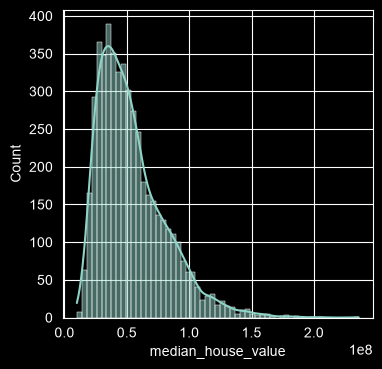

In [16]:
target = 'median_house_value'
plt.figure(figsize=(4,4))
sns.histplot(
    df[target],
    kde=True,
)
plt.show()

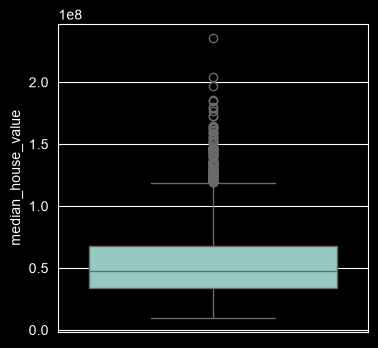

In [17]:
plt.figure(figsize=(4,4))
sns.boxplot(
    df[target], )
plt.show()

In [18]:
df[target].value_counts()

median_house_value
57052454.3    1
26030799.5    1
39670076.9    1
20994180.3    1
45134327.6    1
             ..
31835035.5    1
60361140.9    1
20143824.9    1
29227545.6    1
48414998.6    1
Name: count, Length: 5000, dtype: int64

In [19]:
pd.get_dummies(df["district"])

,Алатауский,Алмалинский,Ауэзовский,Бостандыкский,Жетысуский,Медеуский,Наурызбайский,Турксибский
0,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,True,False,False
4996,False,False,False,False,False,True,False,False
4997,False,False,False,False,False,False,True,False
4998,True,False,False,False,False,False,False,False


NameError: name 'df_encoded' is not defined

In [21]:
y=df[target]
X=df.drop(target,axis=1)
X = pd.get_dummies(X)
print(X.columns.tolist())

['housing_median_age', 'total_rooms', 'total_bedrooms', 'total_floors', 'ceiling_height', 'total_area', 'metro_distance_km', 'district_Алатауский', 'district_Алмалинский', 'district_Ауэзовский', 'district_Бостандыкский', 'district_Жетысуский', 'district_Медеуский', 'district_Наурызбайский', 'district_Турксибский', 'building_type_каркасно-монолитный', 'building_type_кирпичный', 'building_type_монолитный', 'building_type_панельный', 'proximity_БЛИЗ ЦЕНТРА', 'proximity_ГОРЫ', 'proximity_ОКРАИНА', 'proximity_СПАЛЬНЫЙ', 'proximity_ЦЕНТР']


In [32]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [33]:
rf=RandomForestRegressor(
    n_estimators=150,
    oob_score=True,
    random_state=42,
)

In [34]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print("r2=", r2_score (y_test, y_pred))
print('MAE=', mean_absolute_error (y_test, y_pred))
print("RMSE=", root_mean_squared_error (y_test, y_pred))

r2= 0.934068030792277
MAE= 5120611.684523998
RMSE= 6980676.398132519


In [35]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
)

In [36]:
model_xgb.fit(X_train, y_train)
y_predxgb = model_xgb.predict(X_test)
print("r2=", r2_score (y_test, y_predxgb))
print('MAE=', mean_absolute_error (y_test, y_predxgb))
print("RMSE=", root_mean_squared_error (y_test, y_predxgb))

r2= 0.9281695960944495
MAE= 5298266.3067
RMSE= 7286242.757708709


In [37]:
model_cat = CatBoostRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
)

In [38]:
model_cat.fit(X_train, y_train)
y_predcat = model_xgb.predict(X_test)
print("r2=", r2_score (y_test, y_predcat))
print('MAE=', mean_absolute_error (y_test, y_predcat))
print("RMSE=", root_mean_squared_error (y_test, y_predcat))

0:	learn: 24809999.0276787	total: 154ms	remaining: 2m 34s
1:	learn: 22897179.0357456	total: 164ms	remaining: 1m 21s
2:	learn: 21157189.4686524	total: 174ms	remaining: 57.9s
3:	learn: 19601822.1507460	total: 185ms	remaining: 46.1s
4:	learn: 18272295.2250138	total: 197ms	remaining: 39.2s
5:	learn: 17057841.4820508	total: 208ms	remaining: 34.5s
6:	learn: 15877198.3368189	total: 218ms	remaining: 30.9s
7:	learn: 14852848.4673928	total: 227ms	remaining: 28.2s
8:	learn: 13929341.9230014	total: 238ms	remaining: 26.2s
9:	learn: 13106494.3398139	total: 247ms	remaining: 24.4s
10:	learn: 12364422.5812182	total: 257ms	remaining: 23.1s
11:	learn: 11766046.9295819	total: 267ms	remaining: 21.9s
12:	learn: 11168754.3787213	total: 276ms	remaining: 20.9s
13:	learn: 10675041.1721118	total: 287ms	remaining: 20.2s
14:	learn: 10162248.6172011	total: 295ms	remaining: 19.4s
15:	learn: 9776829.7183295	total: 305ms	remaining: 18.7s
16:	learn: 9444884.1379206	total: 315ms	remaining: 18.2s
17:	learn: 9148419.27968

In [42]:
joblib.dump(model_cat, '../model/2version_on_catboost_cat.pkl')

['../model/2.1version_on_catboost_cat.pkl']

In [23]:
joblib.dump(X.columns.tolist(), "../model/columns.pkl")

['../model/columns.pkl']